In [3]:
# Input should be the folder name
# Loops through each file and locally stores the data
# Saves the don't want to grab all the data need define objective function first
# Define an objective function
# Sort either chi_matrices/or phase spaces
# Grabs 



In [5]:
import sys
#sys.path.append('/Users/calvinsmith/dufresne_lab/phase_space_search')

print(sys.path)

import flory_classifier_v2 
from flory_classifier_v2 import FloryClassifier
import h5py
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os

importlib.reload(flory_classifier_v2)


['C:\\Users\\labuser\\Documents\\git\\softliv', 'C:\\Users\\dm967\\Documents\\git\\softliv', 'c:\\Users\\labuser\\Documents\\git\\LLPS_Project\\phase_space_search', 'c:\\Users\\labuser\\.conda\\envs\\llps\\python313.zip', 'c:\\Users\\labuser\\.conda\\envs\\llps\\DLLs', 'c:\\Users\\labuser\\.conda\\envs\\llps\\Lib', 'c:\\Users\\labuser\\.conda\\envs\\llps', '', 'c:\\Users\\labuser\\.conda\\envs\\llps\\Lib\\site-packages', 'c:\\Users\\labuser\\.conda\\envs\\llps\\Lib\\site-packages\\win32', 'c:\\Users\\labuser\\.conda\\envs\\llps\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\labuser\\.conda\\envs\\llps\\Lib\\site-packages\\Pythonwin']


c:\Users\labuser\.conda\envs\llps\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.1.3
2.1.3


<module 'flory_classifier_v2' from 'c:\\Users\\labuser\\Documents\\git\\LLPS_Project\\phase_space_search\\flory_classifier_v2.py'>

In [6]:
folder_path = os.path.normpath(r"C:/Users/labuser/Documents/git/LLPS_Project/phase_space_search/Saved_Phase_Data/Test_Run_2_19_2025")
file_path = r"C:/Users/labuser/Documents/git/LLPS_Project/phase_space_search/Saved_Phase_Data/Test_Run_2_19_2025/grid_phase_data_v2_20250225_141243_chi_2_2105263157894735.h5"


In [7]:
        

# Open the HDF5 file
with h5py.File(file_path, 'r') as hf:
    for chi_key in hf.keys():
        print(f"\n📂 {chi_key}:")  # Print the chi_matrix group name
        
        g1 = hf[chi_key]
        
        # Print initial data
        print("  ├── initial_points:", g1["initial_points"][:].shape)
        print("  ├── chi_matrix:", g1["chi_matrix"][:].shape)
        
        # Access evolved phases
        if "evolved_phases" in g1:
            g2 = g1["evolved_phases"]
            print("  ├── evolved_phases:")
            print("      ├── volumes:", g2["volumes"][:].shape)
            print("      ├── comp_fracs:", g2["comp_fracs"][:].shape)
            print("      ├── num_phases:", g2["num_phases"][:].shape)
            
            # Optionally print a small sample of the data
            print("      ├── num_phases sample:", g2["num_phases"][:5])  # First 5 values



📂 chi_matrix_0:
  ├── initial_points: (171, 3)
  ├── chi_matrix: (3, 3)
  ├── evolved_phases:
      ├── volumes: (171, 3)
      ├── comp_fracs: (171, 2, 3)
      ├── num_phases: (171,)
      ├── num_phases sample: [2. 2. 2. 2. 2.]

📂 chi_matrix_1:
  ├── initial_points: (171, 3)
  ├── chi_matrix: (3, 3)
  ├── evolved_phases:
      ├── volumes: (171, 3)
      ├── comp_fracs: (171, 2, 3)
      ├── num_phases: (171,)
      ├── num_phases sample: [2. 2. 2. 2. 2.]

📂 chi_matrix_2:
  ├── initial_points: (171, 3)
  ├── chi_matrix: (3, 3)
  ├── evolved_phases:
      ├── volumes: (171, 3)
      ├── comp_fracs: (171, 2, 3)
      ├── num_phases: (171,)
      ├── num_phases sample: [2. 2. 2. 2. 2.]


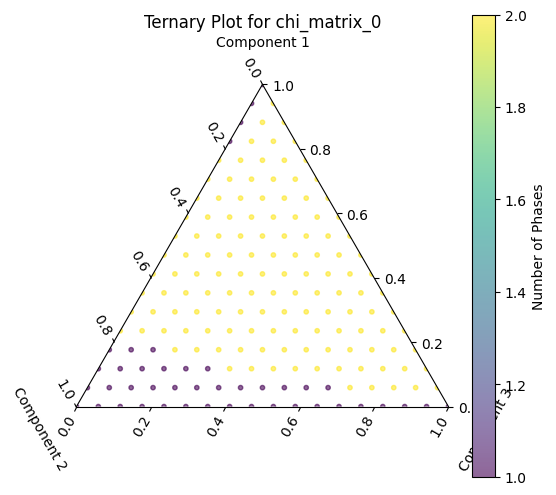

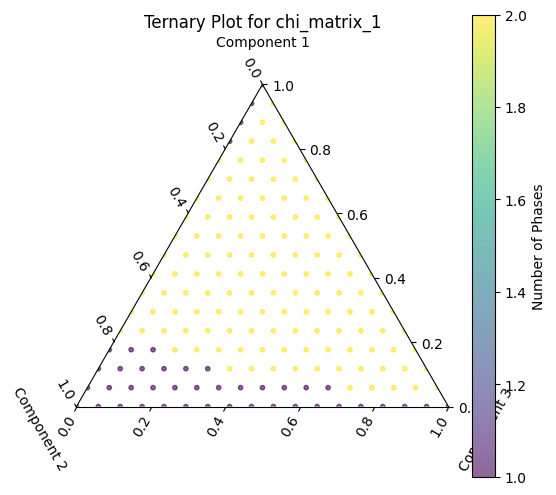

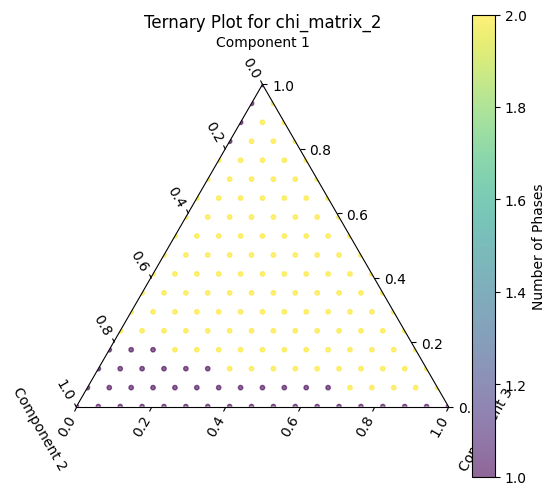

In [8]:



# Open the HDF5 file
with h5py.File(file_path, 'r') as hf:
    for chi_key in hf.keys():
        g1 = hf[chi_key]

        # Extract initial points and number of phases
        points = g1["initial_points"][:]
        num_phases = np.ravel(g1["evolved_phases"]["num_phases"][:])  # Flatten to 1D

        # Normalize points for ternary plot (ensure they sum to 1)
        points /= np.sum(points, axis=1, keepdims=True)

        # Create a ternary plot using mpltern
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'ternary'})

        # Plot initial points with color indicating the number of phases
        scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                             c=num_phases, cmap='viridis', alpha=0.6, s=10)

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("Number of Phases")

        # Set ternary axis labels
        ax.set_tlabel("Component 1")
        ax.set_llabel("Component 2")
        ax.set_rlabel("Component 3")
        # Title
        ax.set_title(f"Ternary Plot for {chi_key}")

        # Show plot

In [ ]:
#Grab all the chi matrices

folder_path = os.path.normpath(r"C:/Users/labuser/Documents/git/LLPS_Project/phase_space_search/Saved_Phase_Data/Test_Run_2_19_2025")

count = 1
for file in os.listdir(folder_path):
    if file.endswith(".hdf5"):
        count += 1 
        file_name = os.path.join(folder_path, file)
        with h5py.File(file_path, 'r') as hf:
            for chi_key in hf.keys():
                g1 = hf[chi_key]
                chi_matrix = g1["chi_matrix"][:]
                
                if count == 1:
                    num_comps = chi_matrix.shape[0]
    
 

In [16]:
               
chi_matrix_holder = np.zeros([count, num_comps,num_comps])


for i,file in enumerate(os.listdir(folder_path)):
    if file.endswith(".hdf5"):
        file_name = os.path.join(folder_path, file)
        with h5py.File(file_path, 'r') as hf:
            for chi_key in hf.keys():
                    g1 = hf[chi_key]
                    chi_matrix = g1["chi_matrix"][:]
                    chi_matrix_holder[i]
                
